# 04. Vision Models

## GAN Problems

- Incredibly hard to train.
    - You have to really pay attension to the learning_rate
    - Use the best optimizers
        - AdamW for Images
    - Curate your dataset carefully
    - Still the loss function explodes to infinity and you have to go back a couple of steps and retry
        - Add noise
        - Reinitialize some of the weights
        - Train again
- Very unstable in general during training, but give good results
- Mode collapse
    - If the generator finds 1 good image, it starts to generate only that image
 
## GAN vs Diffusion control

- Diffusion is more easily controlled with text prompts
- GANs are more easily controlled with numbers
    - The Wasserstein Generative Adversarial Network (WGAN) is a variant of generative adversarial network (GAN) proposed in 2017 that aims to "improve the stability of learning, get rid of problems like mode collapse, and provide meaningful learning curves useful for debugging and hyperparameter searches".
    - Compared with the original GAN discriminator, the Wasserstein GAN discriminator provides a better learning signal to the generator. This allows the training to be more stable when generator is learning distributions in very high dimensional spaces.
    - This allows us to control and also UNDERSTAND what the GAN does. At certain numbers we know what happens.

## Reasons not to use DNN for CV

1. Specific hardware constraints (LLMS are big and heavy) edge devices for example
2. We want interpretability
3. There is no similar task (usually if there is, transfter learning is very easy in CV)

In [12]:
import os
# 0 = all messages (default)
# 1 = filter out INFO
# 2 = filter out INFO and WARNING (This is usually the sweet spot)
# 3 = filter out INFO, WARNING, and ERROR
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import keras
import matplotlib.pyplot as plt

from keras.datasets import cifar10

from keras.models import Sequential
from keras.layers import Input, Flatten, Conv2D, Dense, Dropout, SpatialDropout2D, BatchNormalization, \
MaxPooling2D, GlobalAvgPool2D, RandomZoom, RandomFlip, RandomColorJitter, RandomGrayscale
from keras import regularizers

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

Here we can load the whole dataset in memory, but this almost never happens. This example is small for easy of use and simplicity, but usually we have to work with chunks of the dataset one at a time.

In [3]:
(x_train.shape, y_train.shape), (x_test.shape, y_test.shape)

(((50000, 32, 32, 3), (50000, 1)), ((10000, 32, 32, 3), (10000, 1)))

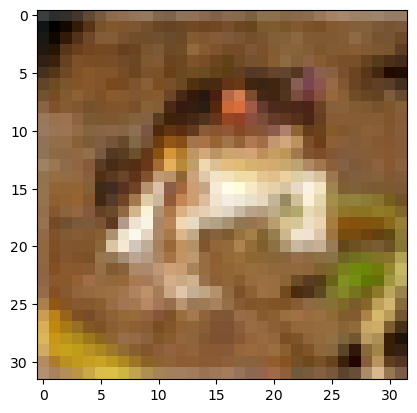

In [7]:
plt.imshow(x_train[0])

In [9]:
model = Sequential([
    Input(shape = (32, 32, 3)),
    Conv2D(filters = 128, kernel_size = 3) # power of 2 usually for filters, kernel_size = 3 or (3, 3) it is the same thing, has to be odd usually
])

I0000 00:00:1770401831.098817    2682 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6100 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060 SUPER, pci bus id: 0000:08:00.0, compute capability: 7.5


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 128)    │         3,584 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,584 (14.00 KB)

 Trainable params: 3,584 (14.00 KB)

 Non-trainable params: 0 (0.00 B)

Conv2D saves a lot of params.

Usually if we have an image (2000 x 2000 x 3) x (256 Dense layer) this explodes to be billions. A whole LLM is that many params. Insane. This is just from a flatten of an ordinary image.

But we don't want Dense layers, since not all pixels make sense to be looked at together. So we pick a small sliding window (convolution) and use that instead. In our case we have 128 filters that are 3x3, much better.

Now the params are (2000 * 2000 * 128)  not 3 billion.

The filters are initialized with RANDOM numbers, not 1s or 0s.


In [17]:
model.layers[0].weights[0] # weights

<Variable path=sequential/conv2d/kernel, shape=(3, 3, 3, 128), dtype=float32, value=[[[[-0.044707    0.04708423  0.0105571  ... -0.04977095  0.001133
    -0.03004128]
   [-0.00498591  0.06881107 -0.07103527 ... -0.06110434 -0.05092895
     0.06522624]
   [-0.07062523  0.00538557 -0.04420482 ... -0.00137028 -0.02430748
    -0.06280994]]

  [[-0.0440601  -0.002037    0.02485721 ...  0.01157731  0.0189785
     0.05246451]
   [-0.01756978 -0.00647321  0.02548226 ...  0.00225684  0.00248189
    -0.0585354 ]
   [ 0.00435665 -0.00599713  0.00771751 ...  0.0280189  -0.03477133
    -0.03555765]]

  [[-0.0420336  -0.02257169 -0.03627925 ... -0.04142127 -0.03638044
     0.01678985]
   [-0.04184063 -0.06407775  0.06921086 ...  0.04875948 -0.04097222
    -0.0100317 ]
   [-0.05037494  0.01008383  0.00584088 ... -0.03358297 -0.02285197
    -0.02552896]]]


 [[[ 0.0320949   0.07082613  0.03564361 ...  0.0523994   0.03029769
    -0.01434621]
   [-0.05872535  0.00359093 -0.05422232 ... -0.04988237 -0.06

In [18]:
model.layers[0].weights[0].shape

TensorShape([3, 3, 3, 128])

In [16]:
model.layers[0].weights[1] #bias

<Variable path=sequential/conv2d/bias, shape=(128,), dtype=float32, value=[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0.]>

The bias is 0 as we can see.

In [20]:
model.layers[0].weights[1].shape

TensorShape([128])

The kernal usually needs to be an odd number so it has a central pixel. This makes the size smaller and smaller with each Conv2D layer, so we can add padding:
- Valid padding - no padding is applied
- Same padding - Adds as many pixels as we would lose in the convolution

## CNN

### Model training

In [42]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

In [43]:
keras.backend.clear_session()
model = Sequential([
    Input(shape = (32, 32, 3)),
    Conv2D(filters = 128, kernel_size = 11, padding = 'same', activation = "relu"), # power of 2 usually for filters, kernel_size = 3 or (3, 3) it is the same thing, has to be odd usually
    Conv2D(filters = 64, kernel_size = 7, padding = 'same', activation = "relu"),
    Conv2D(filters = 32, kernel_size = 5, padding = 'same', activation = "relu"),
    Conv2D(filters = 16, kernel_size = 3, padding = 'same', activation = "relu"),

    Flatten(),
    Dense(units = 10, activation = "softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 128)    │        46,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │       401,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │        51,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │       163,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 667,770 (2.55 MB)

 Trainable params: 667,770 (2.55 MB)

 Non-trainable params: 0 (0.00 B)

We can use "relu" for an activation function, but some of the neurons can be left "dead". I wouldn't use RELU in general, better options exist.

Images are harder to understand than text. They have more information density.

In [44]:
model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics = ["accuracy"])

In [45]:
model.fit(x_train, y_train, epochs = 3)

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 19ms/step - accuracy: 0.3604 - loss: 1.7500
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.4954 - loss: 1.4070
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.5525 - loss: 1.2567


In [46]:
model.fit(x_train, y_train, epochs = 7)

Epoch 1/7
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.5956 - loss: 1.1444
Epoch 2/7
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.6318 - loss: 1.0419
Epoch 3/7
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.6667 - loss: 0.9436
Epoch 4/7
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.7039 - loss: 0.8436
Epoch 5/7
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.7354 - loss: 0.7538
Epoch 6/7
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.7625 - loss: 0.6698
Epoch 7/7
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.7900 - loss: 0.5939


In [47]:
model.fit(x_train, y_train, epochs = 10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.8128 - loss: 0.5300
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.8351 - loss: 0.4659
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.8540 - loss: 0.4118
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.8701 - loss: 0.3642
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.8812 - loss: 0.3328
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.8906 - loss: 0.3051
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.9002 - loss: 0.2804
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.9066 - loss: 0.2658
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.9107 - loss: 0.2506
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.9178 - loss: 0.2296


With LLM transformers, we usually 1 or 2 MAX epochs. If it sees the data again it will overfit.

With Images, that is not the case. Usually you can see, 1000, 3000, 10000 epochs of seeing the same data again and again and we use more conservative learning_rates.

In [48]:
model.evaluate(x_test, y_test)

2026-02-06 21:15:58.833941: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,32,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,64,32,32]{3,2,1,0}, f32[32,64,5,5]{3,2,1,0}, f32[32]{0}), window={size=5x5 pad=2_2x2_2}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-02-06 21:15:59.089702: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,16,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,32,32,32]{3,2,1,0}, f32[16,32,3,3]{3,2,1,0}, f32[16]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__c

308/313 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5046 - loss: 3.5531

2026-02-06 21:16:02.262187: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[16,32,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,64,32,32]{3,2,1,0}, f32[32,64,5,5]{3,2,1,0}, f32[32]{0}), window={size=5x5 pad=2_2x2_2}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-02-06 21:16:02.419799: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[16,16,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,32,32,32]{3,2,1,0}, f32[16,32,3,3]{3,2,1,0}, f32[16]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__c

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.5060 - loss: 3.6015


[3.6015305519104004, 0.5059999823570251]

We see a lot of overfitting. So lets regularaize

We can use a parametern on Conv2D() layer or we can use Dropout(). 

For Convolutions it is actually really good to use the layer param. Do not use Dropout, because instead of removing some filters/kernals it removes part of them. We don't want that.

We could use SpatialDropout2D() which does that filter removal.

In [66]:
model = Sequential([
    Input(shape = (32, 32, 3)),
    Conv2D(filters = 128, kernel_size = 3, padding = 'same', activation = "relu", kernel_regularizer=regularizers.L1L2(l1=1e-5, l2=1e-4)), # power of 2 usually for filters, kernel_size = 3 or (3, 3) it is the same thing, has to be odd usually
    BatchNormalization(),
    MaxPooling2D(),
    Conv2D(filters = 64, kernel_size = 3, padding = 'same', activation = "relu"),
    SpatialDropout2D(0.1),
    Conv2D(filters = 32, kernel_size = 3, padding = 'same', activation = "relu", kernel_regularizer=regularizers.L1L2(l1=1e-5, l2=1e-4)),
    BatchNormalization(),
    MaxPooling2D(),
    Conv2D(filters = 16, kernel_size = 3, padding = 'same', activation = "relu"),
    SpatialDropout2D(0.1),
    
    Flatten(),
    Dropout(0.4),
    Dense(units = 10, activation = "softmax")
])

model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics = ["accuracy"])
model.fit(x_train, y_train, epochs = 10, validation_split=0.05)

model.summary()

Epoch 1/10


2026-02-06 21:36:50.633020: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,128,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,3,32,32]{3,2,1,0}, f32[128,3,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-02-06 21:36:50.653547: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,64,16,16]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,128,16,16]{3,2,1,0}, f32[64,128,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="

1483/1485 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3513 - loss: 1.8199 

2026-02-06 21:37:03.196959: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[12,128,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[12,3,32,32]{3,2,1,0}, f32[128,3,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-02-06 21:37:03.209006: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[12,64,16,16]{3,2,1,0}, u8[0]{0}) custom-call(f32[12,128,16,16]{3,2,1,0}, f32[64,128,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="

1485/1485 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3514 - loss: 1.8196

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_25 (Conv2D)              │ (None, 32, 32, 128)    │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 16, 16, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_4             │ (None, 16, 16, 64)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 8, 8, 16)       │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_5             │ (None, 8, 8, 16)       │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,424 (1.27 MB)

 Trainable params: 111,034 (433.73 KB)

 Non-trainable params: 320 (1.25 KB)

 Optimizer params: 222,070 (867.46 KB)

In [68]:
model.fit(x_train, y_train, epochs = 10, validation_split=0.05)

Epoch 1/10
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7150 - loss: 0.8518 - val_accuracy: 0.7184 - val_loss: 0.8443
Epoch 2/10
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7177 - loss: 0.8370 - val_accuracy: 0.7576 - val_loss: 0.7656
Epoch 3/10
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7229 - loss: 0.8247 - val_accuracy: 0.7532 - val_loss: 0.7644
Epoch 4/10
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7282 - loss: 0.8087 - val_accuracy: 0.6748 - val_loss: 1.0089
Epoch 5/10
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7319 - loss: 0.7995 - val_accuracy: 0.7312 - val_loss: 0.8320
Epoch 6/10
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7376 - loss: 0.7883 - val_accuracy: 0.7564 - val_loss: 0.7716
Epoch 7/10
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7403 - loss: 0.7783 - val_accuracy: 0.7360 - val_loss: 0.8260
Epoch 8/10
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7434 - loss: 0.7683 - 

In [69]:
model.fit(x_train, y_train, epochs = 20, validation_split=0.05)

Epoch 1/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7510 - loss: 0.7498 - val_accuracy: 0.7696 - val_loss: 0.7270
Epoch 2/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7544 - loss: 0.7406 - val_accuracy: 0.7732 - val_loss: 0.7369
Epoch 3/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7606 - loss: 0.7289 - val_accuracy: 0.7536 - val_loss: 0.7600
Epoch 4/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7620 - loss: 0.7238 - val_accuracy: 0.7520 - val_loss: 0.7701
Epoch 5/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7632 - loss: 0.7179 - val_accuracy: 0.7588 - val_loss: 0.7889
Epoch 6/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7685 - loss: 0.7095 - val_accuracy: 0.7636 - val_loss: 0.7263
Epoch 7/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7677 - loss: 0.7032 - val_accuracy: 0.7800 - val_loss: 0.6970
Epoch 8/20
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7698 - loss: 0.7021 - 

We can add early stopping, or a scheduler to reduce learning_rate when it detects this behaviour. Also make the conv2D 2 consecutive. On and on. Play around.

### MaxPooling

Max pooling is a downsampling technique in convolutional neural networks (CNNs) that reduces the spatial dimensions (width, height) of input feature maps by taking the maximum value within a window (commonly (2 x 2)). It reduces computational load, prevents overfitting, and provides spatial invariance, allowing the network to detect features regardless of their exact position. 

Seems to have fixed the problem we had. But we can't push past 70% now. We can even see the accuracy went down from 76% to 66%, while the val score sat still at 78%

Good practice is to make maxpooling after a couple of Conv2D layers (a block of them)

<img src="Images/maxpooling.png" width=400>

### Stride

The number of pixels the convolutional filter (kernel) shifts over the input matrix in a single step during the convolution operation

<img src="Images/stride.png" width=400>

Lets see an example how it affects the Output Shape

In [10]:
model = Sequential([
    Input(shape = (2000, 200, 3)),
    Conv2D(20, kernel_size = 3, padding = "same")
])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 2000, 200, 20)  │           560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 560 (2.19 KB)

 Trainable params: 560 (2.19 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model = Sequential([
    Input(shape = (2000, 200, 3)),
    Conv2D(20, kernel_size = 3, padding = "same", strides = 2)
])

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 1000, 100, 20)  │           560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 560 (2.19 KB)

 Trainable params: 560 (2.19 KB)

 Non-trainable params: 0 (0.00 B)

### Dilation rate

Useful when we have big and small features in the image. This kind of zooms out and has a bigger picture view.

We do convolution, but we dont take neighbouring pixels, we skip a couple:

<img src="Images/dilation.png" width=300>

### Image pyramid

We can train a couple of different models each with different input/output shapes. We scale down the image (usually by a factor of 2) and predict on all of the models at the same time. (2000, 2000) -> (1000, 1000) -> ...

Useful for scale invariant. Meaning the size of the features won't matter. Same is done in image stitching algorithms.

<img src="Images/image_pyramid.png" width=400>

### GlobalAveragePooling

Flatten makes a bit too many parameters on the penultimate layer, we can replace it with global pooling

Global Average Pooling (GAP) is a dimensionality reduction technique in deep learning that replaces fully connected layers in CNNs by averaging entire h x w feature maps into single 1 x 1 values. This approach reduces parameter count, mitigates overfitting, and provides spatial invariance, making models more robust and faster to train

It does the average pooling operation, not on a 2x2 block, but on the whole 16x16 image in the end. Hence 32 Output shape.

<img src="Images/flatten.png" width=600><img src="Images/global_average_pooling.png" width=600>

In general, pooling loses a lot of information(very serious dim reduction). If we have a small image size at the last layers, flatten() does a better job than global pooling. 

### Invariance of CNN

CNN are invariant for translations. Which means they don't care where the eye is. Top left corder or bottom right. It will still recognize it.

Problem comes with rotation.

You can have 99% accruacy on a dataset, but when you rotate every picture by 1% to the right all of a suddent we start getting 10% accuracy.

#### The solution to rotation: Data augmentation

There is only one. FORCE!

Roatate the dataset and give it to the model. Data augmentation.

### Data augmentation

Data augmentation is a technique in machine learning used to reduce overfitting when training a machine learning model,by training models on several slightly-modified copies of existing data. When convolutional neural networks grew larger in mid-1990s, there often was not enough available data to train them, especially considering that some part of the overall dataset should be spared for later testing. It was proposed to perturb existing data with affine transformations to create new examples with the same labels, which were complemented by so-called elastic distortions in 2003,and the technique was widely used as of 2010s.

In [38]:
augmentation = Sequential([
    RandomGrayscale(),
    RandomColorJitter(),
    RandomZoom(0.3),
    RandomFlip()
])

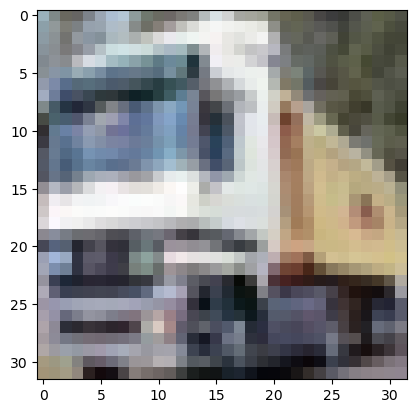

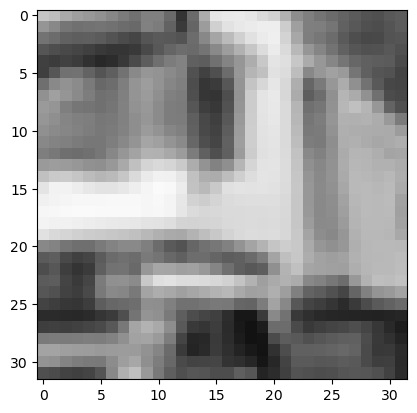

In [42]:
plt.imshow(x_train[1])
plt.show()

aug_images = augmentation(x_train[:2], training=True)  # Training-True, because the augementation layers are disabled on inference
plt.imshow(aug_images[1].numpy().astype("uint8"))

## Vision Transformers

### Image Patching

An old technique. We splice the image into smaller patches and then work with them.

<img src="Images/image_patching.png" width=600>

Ok lets do the following. We split the image into patches, then Flatten() each patch and give it a number. This way we can think of it as working with sequences of patches.

<img src="Images/image_patch_sequences.png" width=1000>

What we have a is vectors with positions. Well that is what Transformers use, so we can just plug it into a transformer and it will work!

Here come ViT (Vision Transformers)

<img src="Images/vision_transformers.png" width=1000>

1. Slice into patches
2. Flatten
3. The embeddings (a dense layer without a bias term, used to reduce dimentionality) reduce the size
4. Add positions to the reduced vector patches
5. A standard transformer
6. Profit

### How does this work tho?

We said using flatten isn't great. We are using patches that break the whole point of Convolutions. So how the hell does this work?

CNN have less parameters are doing great and fast at many tasks, but if you want a foundational model that understands from everything, that requires too complex convolutions

One isn't better than the other. They have different use cases

(Gemini)\
<img src="Images/cnn_vs_vit.png" width=700>

ViTs best pro is that they can be trained on a lot more data, where CNNs fail

## Hybrids

Why not use a CNN for each patch and then apply the attension maps on them?

Well, yeah. That is the standard atm.  

### [ConvNext](https://arxiv.org/pdf/2201.03545)

Biggest breakthrough in CV in the last 5 years.

It is a hybrid of CNN and Transformers.

### Problem

We want a really good model. So we make a lot of parameters. This means more layers. This means longer train times.

Problem comes with the number of layers. 

<img src="Images/problem.png" width=1000>

In this picture we can see 2 models. A 56 layers complex model and a 20 layer simpler model. 

It makes sense for the more complex model to be able to overfit the data more, right? Correct.\
Then why do we not see that? It seems to be the opposite?

The problem comes with the number of calculations that need to happen. The RAM is limited and the more calculations you make the more inaccuracy stacks. So larger models have this issue. 

Numbers close to 0 become 0 and numbers close to infinity become infinity.

#### This is called Vanishing Gradients problem

There isn't a direct fix. There are diffrent ways to deal with it.

In attension: Sparse attension. Make it not look at the every pair of tokens. More attension blocks and normalize them before and after.
In RNN: Gates
CNN: Skip connections or also called Residual connections

This is where the RNN name comes from. Very simple idea.

#### RNN

Residual Neural Networks\
Residual connection / Skip connection

Conv layer with Kernal 1x1 is a Dense layer implemented as Conv layer (often used)\
BN - Batch Normalization

<img src="Images/rnn.png" width=400>

We add the results of the 3 blocks to their input. The dimensions need to be the same!
So what?
If the gradients vanished on the $ F(x) $ calculations, then we reintroduce them from the $ x $ addition


## Applications

Datasets:
- COCO
- ImageNet

### ConvNeXt

In [43]:
from keras.applications.convnext import ConvNeXtTiny, preprocess_input, decode_predictions

In [44]:
convnext = ConvNeXtTiny()

114735104/114735104 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step 


In [45]:
convnext.summary()

Model: "convnext_tiny"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_pres… │ (None, 224, 224,  │          0 │ input_layer_12[0… │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stem  │ (None, 56, 56,    │      4,896 │ convnext_tiny_pr… │
│ (Sequential)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 56, 56,    │      4,800 │ convnext_tiny_st… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 56, 56,    │        192 │ convnext_tiny_st… │
│ (LayerNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 56, 56,    │     37,248 │ convnext_tiny_st… │
│ (Dense)             │ 384)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 56, 56,    │          0 │ convnext_tiny_st… │
│ (Activation)        │ 384)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 56, 56,    │     36,960 │ convnext_tiny_st… │
│ (Dense)             │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 56, 56,    │         96 │ convnext_tiny_st… │
│ (LayerScale)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 56, 56,    │          0 │ convnext_tiny_st… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 56, 56,    │          0 │ convnext_tiny_st… │
│                     │ 96)               │            │ convnext_tiny_st… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 56, 56,    │      4,800 │ add[0][0]         │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 56, 56,    │        192 │ convnext_tiny_st… │
│ (LayerNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 56, 56,    │     37,248 │ convnext_tiny_st… │
│ (Dense)             │ 384)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 56, 56,    │          0 │ convnext_tiny_st… │
│ (Activation)        │ 384)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 56, 56,    │     36,960 │ convnext_tiny_st… │
│ (Dense)             │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 56, 56,    │         96 │ convnext_tiny_st

 Total params: 28,589,128 (109.06 MB)

 Trainable params: 28,589,128 (109.06 MB)

 Non-trainable params: 0 (0.00 B)

<img src="Images/coco_image_cat.jpg" width=400>

In [62]:
import skimage
from skimage.io import imread
from skimage.transform import resize

cat_image = imread("Images/coco_image_cat.jpg")

In [63]:
cat_image = resize(cat_image, (224, 224), preserve_range = True)

In [64]:
cat_image = cat_image.reshape(1, 224, 224, 3)

In [65]:
convnext.predict(cat_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


array([[1.04089180e-04, 7.75434310e-05, 1.28882064e-04, 9.10303352e-05,
        1.48803476e-04, 5.58291213e-05, 9.30038586e-05, 1.48278123e-04,
        9.46405125e-05, 8.65464681e-05, 1.30898174e-04, 2.08333673e-04,
        1.24394544e-04, 6.62489110e-05, 1.15323615e-04, 1.67001519e-04,
        1.03401951e-04, 8.00604903e-05, 1.79946219e-04, 9.64292922e-05,
        1.97606147e-04, 1.37962386e-04, 7.64217984e-05, 1.45107973e-04,
        1.29406602e-04, 1.07101929e-04, 9.96663512e-05, 1.76509231e-04,
        2.18862580e-04, 6.91482273e-05, 2.35710657e-04, 2.14246757e-04,
        1.44473146e-04, 8.84371984e-05, 1.29806591e-04, 5.01285831e-05,
        2.67842406e-04, 1.39244075e-04, 3.98467382e-04, 1.68128841e-04,
        1.64659621e-04, 1.47637315e-04, 4.06241743e-04, 1.86500911e-04,
        2.20004658e-04, 1.02293910e-04, 1.90785853e-04, 2.70576536e-04,
        9.76153024e-05, 1.07615801e-04, 1.14288312e-04, 9.37770164e-05,
        1.34186223e-04, 8.20529967e-05, 1.82541495e-04, 7.547529

In [66]:
decode_predictions(convnext.predict(cat_image))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


[[('n02123045', 'tabby', 0.4105549),
  ('n02123159', 'tiger_cat', 0.34357724),
  ('n02124075', 'Egyptian_cat', 0.09067576),
  ('n04033995', 'quilt', 0.0028469467),
  ('n03938244', 'pillow', 0.001787753)]]

Looks like a cat!

### Big tasks for CV

- Object Detection
- Text and Image Recognition

### CLIP

The first DNN that manages to embed text and images in the same space.

OpenAI model that understands text and images at the same time

<img src="Images/clip.png" width=700>

We make embeddings for the text and the images.\
Then create an attension correlation matrix and try to minimize the distances on the diagonal.

We match each token of the text to each patch of the image

Able to calculate distance from text to image

In [68]:
from transformers import AutoModel

In [69]:
clip = AutoModel.from_pretrained("openai/clip-vit-base-patch32")

Loading weights: 100%|█████████████████| 398/398 [00:00<00:00, 738.08it/s, Materializing param=visual_projection.weight]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [71]:
clip

CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

We can see the vision_model and the text_model work in parallel. In the end 

```
(visual_projection): Linear(in_features=768, out_features=512, bias=False)
(text_projection): Linear(in_features=512, out_features=512, bias=False)
```

CLIP is good at image captioning. Give a sentence that describes the image.

### Zero-shot learning
CLIP is good for Zero-shot classification - the model has never seen our classes, but yet it classifies well the unseen data.

Zero-shot learning (ZSL) is a machine learning technique where a model correctly classifies objects or concepts without having seen any labeled training examples of them

### Optical Character Recognition (OCR)

Optical Character Recognition (OCR) is technology that converts images of typed, handwritten, or printed text—such as scanned documents, PDF files, or photos—into machine-encoded, editable, and searchable text. It automates data extraction, eliminating the need for manual data entry. Common uses include digitizing, indexing, and translating documents. 

CLIP does poorly on OCR

### Knowledge distillation

We have 2 NN. A big one and a small one. The goal is the small one to reach the performance of the big one.

In machine learning, knowledge distillation or model distillation is the process of transferring knowledge from a large model to a smaller one. While large models (such as very deep neural networks or ensembles of many models) have more knowledge capacity than small models, this capacity might not be fully utilized. It can be just as computationally expensive to evaluate a model even if it utilizes little of its knowledge capacity. Knowledge distillation transfers knowledge from a large model to a smaller one without loss of validity. As smaller models are less expensive to evaluate, they can be deployed on less powerful hardware (such as a mobile device).[1]

### Types of Image Segmentation

<img src="Images/image_segmentation.png" width=700>

- Semantic image seg - on each channel draw 0 or 1 if the object is there or not. Very useful.
- Instance seg - the cars are different than the people
- Panoptic seg - combines the 2 above. Labeling every pixel in an image. 

### Object detection

Draw a bounding box/cube around the object:

<img src="Images/object_detection.png" width=700>

#### DETR (DEtection TRansformer)

DETR is a good model for this task\
Incredibly memory hungry

<img src="Images/detr.png" width=1200>

#### YOLO (You only look once)

Probably the fastest object detector\
Not that accurate obv. But can do alot of things

### Qwen

Very good LLM that works with Images

### GEMMA

The Gemini's Open-Source model. 

Understands text, image and instructions.

## Explainability

### CNN
CNNs are kind of figures out

Good way to see what your model actually understands/catches
- Humans catch contrasts, lines, edges, objects
- CNNs catch textures, not where are the boundaries of the object

1. Activation atlases - similar to PCA. It shows where particular feature maps are located in the latent space.
    - <img src="Images/cnn_expl.png" width=700>
    - You can see these "images" are not actual images of object, they are feature maps. They look like things. An understanding of a thing more like.
    - Use to examine the manifold
    - Use to try to find classes
2. Samilence maps
    - <img src="Images/saliency_map.png" width=400>
    - How strongly a part of the image activates a particular class
    - Uses masks
       - Hide part of the image and ask is this an elephant. If there is a big difference in the predictions of with/without the hiding then it matters
    - Works only with models that can do calssification
3. Attension Rollout
    - For transformers
    - <img src="Images/vit_expl.png" width=600>
    - Split the model into pieces and see which parts of the model contribute how much to the final prediction
    - Each attension head gives better and better results
    - It should be a funnel, used to understand how well the model was trained
    - Above we saw the distances between tokens and how it changes with each head, here we can show the distances(kind of like saliency map):
    - <img src="Images/attension_rollout.png" width=600>
    - Attension heatmap
    - <img src="Images/attension_heatmaps.png" width=500>

## [Late fusion](https://www.v7labs.com/blog/multimodal-deep-learning-guide)

<img src="Images/late_fusion.png" width=600>

Combine the different modalities in the end.

Might need to do this in my project!